# Real RAG Comparison: Traditional vs RAPTOR (Weaviate + Ollama)

This notebook implements and compares real Traditional RAG and RAPTOR RAG systems using:
- **Weaviate** vector database (your existing setup)
- **Ollama** for local LLM inference (completely free)
- **Real NVIDIA documents** from your existing collections

## Benefits:
- ✅ **100% Free** - No API costs
- ✅ **Private** - All processing stays local
- ✅ **Fast** - Local inference with modern models
- ✅ **Flexible** - Easy to switch between models

In [1]:
# Install required packages
!pip install -q weaviate-client langchain-weaviate langchain_community langchain-ollama tiktoken sentence-transformers rouge-score nltk plotly umap-learn scikit-learn

In [2]:
# Check if Ollama is installed and running
import subprocess
import sys

def check_ollama():
    """Check if Ollama is installed and running"""
    try:
        result = subprocess.run(['ollama', '--version'], capture_output=True, text=True, timeout=10)
        if result.returncode == 0:
            print(f"✅ Ollama installed: {result.stdout.strip()}")
            return True
        else:
            print("❌ Ollama not found")
            return False
    except (subprocess.TimeoutExpired, FileNotFoundError):
        print("❌ Ollama not installed or not in PATH")
        print("\n📥 To install Ollama:")
        print("   Visit: https://ollama.ai")
        print("   Or run: curl -fsSL https://ollama.ai/install.sh | sh")
        return False

def check_ollama_models():
    """Check available Ollama models"""
    try:
        result = subprocess.run(['ollama', 'list'], capture_output=True, text=True, timeout=10)
        if result.returncode == 0:
            print("\n📋 Available Ollama models:")
            print(result.stdout)
            return result.stdout
        else:
            print("❌ Could not list Ollama models")
            return None
    except subprocess.TimeoutExpired:
        print("❌ Timeout checking Ollama models")
        return None


ollama_available = check_ollama()
if ollama_available:
    models_output = check_ollama_models()
    print(models_output)

✅ Ollama installed: ollama version is 0.12.11

📋 Available Ollama models:
NAME          ID              SIZE      MODIFIED    
qwen2.5:7b    845dbda0ea48    4.7 GB    2 weeks ago    

NAME          ID              SIZE      MODIFIED    
qwen2.5:7b    845dbda0ea48    4.7 GB    2 weeks ago    



In [3]:
import os
import glob
import json
import re
import time
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import tiktoken
import weaviate
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

# LangChain imports
from langchain_ollama import ChatOllama
from langchain_weaviate.vectorstores import WeaviateVectorStore
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.documents import Document

# Evaluation imports
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer
import nltk

# Download NLTK data with better error handling
print("🔽 Downloading required NLTK data...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("✅ NLTK data downloaded successfully")
except Exception as e:
    print(f"⚠️  Warning: Could not download some NLTK data: {e}")
    print("   This won't affect the main functionality")

# Set environment variables to avoid warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Set random seed for reproducibility
RANDOM_SEED = 42 #224
np.random.seed(RANDOM_SEED)

print("✅ All imports loaded successfully!")

🔽 Downloading required NLTK data...
✅ NLTK data downloaded successfully
✅ All imports loaded successfully!


In [4]:
# Configuration
# Weaviate Configuration
WEAVIATE_URL = "http://localhost:8080"
EXISTING_COLLECTION_NAME = "NvidiaInfo"  # Your existing collection
RAPTOR_COLLECTION_NAME = "NvidiaRAPTOROllama"  # New collection for RAPTOR

# Ollama Model Configuration
OLLAMA_MODEL = "qwen2.5:7b"  # Change this if you prefer a different model # "sentence-transformers/all-mpnet-base-v2"
HF_MODEL = "BAAI/bge-base-en-v1.5"
# Alternative options:
# "qwen2.5:7b"  # Better quality, slower
# "mistral:7b"  # Good balance
# "llama3.2:1b" # Fastest, lower quality

# Initialize models
try:
    print(f"🤖 Initializing Ollama with model: {OLLAMA_MODEL}")
    llm = ChatOllama(
        model=OLLAMA_MODEL,
        temperature=0,
        # Adjust these parameters based on your hardware
        num_ctx=4096,  # Context length
        num_predict=512,  # Max tokens to generate
        timeout=120  # Timeout in seconds
    )
    
    # Test the model
    test_response = llm.invoke("Hello! Respond with just 'OK' if you're working.")
    print(f"✅ Ollama model ready! Test response: {test_response.content[:50]}")
    
except Exception as e:
    print(f"❌ Error initializing Ollama: {e}")
    print(f"\n🔧 Troubleshooting:")
    print(f"1. Make sure Ollama is running")
    print(f"2. Download the model: ollama pull {OLLAMA_MODEL}")
    print(f"3. Check available models: ollama list")

# Initialize embeddings (same as your existing setup)
hf_embeddings = HuggingFaceEmbeddings(model_name=HF_MODEL)
print(f"✅ HuggingFace embeddings initialized{HF_MODEL}" )

# Data paths
DATA_PATH = "/data"
WEAVIATE_PATH = "/weaviate"

print("\n🎯 Configuration completed!")
print(f"   Weaviate URL: {WEAVIATE_URL}")
print(f"   Ollama Model: {OLLAMA_MODEL}")
print(f"   Embeddings: {HF_MODEL}")

🤖 Initializing Ollama with model: qwen2.5:7b
✅ Ollama model ready! Test response: OK


/var/folders/gb/c4nt6cmx0619g3t303wp940w0000gn/T/ipykernel_88269/1698193091.py:39: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  hf_embeddings = HuggingFaceEmbeddings(model_name=HF_MODEL)


✅ HuggingFace embeddings initializedBAAI/bge-base-en-v1.5

🎯 Configuration completed!
   Weaviate URL: http://localhost:8080
   Ollama Model: qwen2.5:7b
   Embeddings: BAAI/bge-base-en-v1.5


## 1. Initialize Weaviate and Check Existing Data

In [5]:
def initialize_weaviate_client():
    """Initialize Weaviate client and check connection"""
    try:
        client = weaviate.connect_to_local()
        if not client.is_live():
            print("❌ Weaviate client is not ready. Please start Weaviate:")
            print("cd weaviate")
            print("docker compose up -d")
            return None
        
        print(f"✅ Weaviate client connected successfully at {WEAVIATE_URL}")
        
        # List existing collections - handle v4 API properly
        try:
            collections = client.collections.list_all()
            # collections.list_all() returns a dict-like object in v4
            if hasattr(collections, 'keys'):
                collection_names = list(collections.keys())
            elif hasattr(collections, '__iter__'):
                collection_names = [str(c) for c in collections]
            else:
                collection_names = []
            print(f"\n📚 Existing collections: {collection_names}")
        except Exception as e:
            print(f"⚠️  Could not list collections: {e}")
            collection_names = []
        
        return client
        
    except Exception as e:
        print(f"❌ Could not initialize Weaviate client: {e}")
        print("Make sure Weaviate is running with: docker compose up -d")
        return None

def check_existing_data(client):
    """Check what data exists in your Weaviate collections"""
    try:
        # Try different possible collection names directly
        possible_names = ["NvidiaInfo", "NvidiaNewsArticleHF", "nvidia_all_txt_documents"]
        existing_collection = None
        
        for name in possible_names:
            try:
                if client.collections.exists(name):
                    existing_collection = name
                    print(f"✅ Found collection: {name}")
                    break
            except Exception as e:
                print(f"⚠️  Error checking collection '{name}': {e}")
                continue
        
        if existing_collection:
            try:
                collection = client.collections.get(existing_collection)
                # Get count using the v4 API
                result = collection.aggregate.over_all(total_count=True)
                count = result.total_count
                print(f"\n🎯 Collection '{existing_collection}' has {count} documents")
                
                # Sample a few documents
                sample = collection.query.fetch_objects(limit=3)
                print(f"\n📄 Sample documents:")
                for i, obj in enumerate(sample.objects):
                    props = obj.properties
                    text_preview = props.get('text', '')[:100] + '...' if props.get('text') else 'No text'
                    print(f"  {i+1}. Source: {props.get('source', 'Unknown')}")
                    print(f"     Preview: {text_preview}")
                
                return existing_collection
            except Exception as e:
                print(f"❌ Error accessing collection '{existing_collection}': {e}")
                return None
        else:
            print("\n❌ No NVIDIA collection found.")
            print("\n🔧 To create a collection, run the Weaviate ingestion script:")
            print("   cd weaviate")
            print("   python weaviate_db.py")
            return None
            
    except Exception as e:
        print(f"❌ Error checking existing data: {e}")
        import traceback
        traceback.print_exc()
        return None

# Initialize connection
print("🔌 Connecting to Weaviate...")
client = initialize_weaviate_client()
if client:
    existing_collection_name = check_existing_data(client)
    if existing_collection_name:
        print(f"✅ Ready to use existing collection: {existing_collection_name}")
    else:
        print("⚠️  No existing collection found")
else:
    print("❌ Please start Weaviate and try again.")

🔌 Connecting to Weaviate...
✅ Weaviate client connected successfully at http://localhost:8080

📚 Existing collections: ['NvidiaInfo', 'NvidiaRAPTOROllama']
✅ Found collection: NvidiaInfo

🎯 Collection 'NvidiaInfo' has 7581 documents

📄 Sample documents:
  1. Source: ../data/publications/rag_papers_text/1968587_CITED-63_PETScTAO_Users_Manual_Rev_319.md
     Preview: Debug vs. Optimized Builds

PETSc’s configure defaults to building PETSc with debug mode enabled. An...
  2. Source: ../data/publications/rag_papers_text/2337606_CITED-14_PETScTAO_Users_Manual_V321.md
     Preview: 248

Chapter 4. Additional Information

4.2. Using MATLAB with PETSc

PETSc/TAO Users Manual, Releas...
  3. Source: ../data/publications/rag_papers_text/2337606_CITED-14_PETScTAO_Users_Manual_V321.md
     Preview: :cs find s functionname

opens a list of all of the places the function is called in PETSc, and open...
✅ Ready to use existing collection: NvidiaInfo


## 2. Traditional RAG Implementation (Using Existing Weaviate + Ollama)

In [6]:
class TraditionalRAGOllama:
    """Traditional RAG implementation using Weaviate + Ollama"""
    
    def __init__(self, client, collection_name, embeddings, llm):
        self.client = client
        self.collection_name = collection_name
        self.embeddings = embeddings
        self.llm = llm
        self.vectorstore = None
        self.retriever = None
        self.chain = None
        
    def setup_vectorstore(self):
        """Setup vector store using existing Weaviate collection"""
        print(f"🔧 Setting up Traditional RAG with collection: {self.collection_name}")
        
        try:
            # Initialize LangChain VectorStore with existing collection
            self.vectorstore = WeaviateVectorStore(
                client=self.client,
                index_name=self.collection_name,
                text_key="text",
                embedding=self.embeddings
            )
            
            self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": 5})
            
            # Create RAG chain with Ollama
            prompt = ChatPromptTemplate.from_template(
                """You are an AI assistant specializing in NVIDIA technologies and business. Use the provided context to answer the question accurately and concisely.

Context:
{context}

Question: {question}

Answer: Provide a helpful, accurate response based on the context. If the context doesn't contain enough information, say so."""
            )
            
            def format_docs(docs):
                return "\n\n".join([f"[Source: {doc.metadata.get('source', 'unknown')}]\n{doc.page_content}" for doc in docs])
            
            self.chain = (
                {"context": self.retriever | format_docs, "question": RunnablePassthrough()}
                | prompt
                | self.llm
                | StrOutputParser()
            )
            
            print("✅ Traditional RAG system ready!")
            return True
            
        except Exception as e:
            print(f"❌ Error setting up Traditional RAG: {e}")
            return False
        
    def query(self, question):
        """Query the Traditional RAG system"""
        if not self.chain:
            raise ValueError("RAG system not setup yet. Call setup_vectorstore() first.")
            
        start_time = time.time()
        
        try:
            # Get retrieved documents for analysis
            retrieved_docs = self.retriever.invoke(question)
            answer = self.chain.invoke(question)
            
            end_time = time.time()
            
            return {
                'answer': answer,
                'retrieved_docs': [doc.page_content for doc in retrieved_docs],
                'retrieved_metadata': [{
                    'source': doc.metadata.get('source', 'unknown'),
                    'type': 'original_chunk',
                    'level': 0
                } for doc in retrieved_docs],
                'context_length': sum(len(doc.page_content) for doc in retrieved_docs),
                'response_time': end_time - start_time,
                'num_retrieved': len(retrieved_docs)
            }
        except Exception as e:
            print(f"❌ Error during Traditional RAG query: {e}")
            return {
                'answer': f"Error: {e}",
                'retrieved_docs': [],
                'retrieved_metadata': [],
                'context_length': 0,
                'response_time': 0,
                'num_retrieved': 0
            }

# Initialize Traditional RAG
if client and existing_collection_name:
    print("\n🚀 Initializing Traditional RAG with Ollama...")
    traditional_rag = TraditionalRAGOllama(
        client=client,
        collection_name=existing_collection_name,
        embeddings=hf_embeddings,
        llm=llm
    )
    
    if traditional_rag.setup_vectorstore():
        print("✅ Traditional RAG initialized successfully!")
        
        # Test with a quick query
        print("\n🧪 Quick test query...")
        test_result = traditional_rag.query("What does NVIDIA do?")
        print(f"Test response: {test_result['answer'][:100]}...")
        print(f"Response time: {test_result['response_time']:.2f}s")
    else:
        print("❌ Failed to initialize Traditional RAG")
else:
    print("❌ Cannot initialize Traditional RAG - missing client or collection")


🚀 Initializing Traditional RAG with Ollama...
🔧 Setting up Traditional RAG with collection: NvidiaInfo
✅ Traditional RAG system ready!
✅ Traditional RAG initialized successfully!

🧪 Quick test query...
Test response: NVIDIA focuses on providing technologies and solutions for AI infrastructure, GPU computing, and qua...
Response time: 19.80s


## 3. Load Documents for RAPTOR Processing

In [7]:
def load_documents_from_weaviate(client, collection_name, max_docs=1000):
    """Load documents directly from existing Weaviate collection for RAPTOR processing"""
    print(f"📂 Loading documents from existing Weaviate collection: {collection_name}")
    
    try:
        collection = client.collections.get(collection_name)
        
        # Get documents with strategic sampling for better RAPTOR performance
        result = collection.query.fetch_objects(limit=max_docs * 3, include_vector=False)
        
        documents = []
        doc_type_counts = {}
        
        # Filter and prioritize documents for better RAPTOR clustering
        article_docs = []
        publication_docs = []
        transcript_docs = []
        
        for obj in result.objects:
            props = obj.properties
            text = props.get('text', '')
            source = props.get('source', 'unknown')
            
            if text.strip() and len(text) > 100:  # Only include substantial documents
                # Categorize documents
                if 'nvidia_articles' in source.lower():
                    article_docs.append((obj, 'article', text, source))
                elif 'publications' in source.lower():
                    publication_docs.append((obj, 'publication', text, source))
                elif 'transcripts' in source.lower():
                    transcript_docs.append((obj, 'transcript', text, source))
        
        # Strategic sampling: ensure diverse document types
        target_per_type = max_docs // 3
        selected_docs = []
        
        # Sample from each type
        for doc_list, doc_type in [(article_docs, 'article'), 
                                  (publication_docs, 'publication'), 
                                  (transcript_docs, 'transcript')]:
            # Sort by length to get more substantial documents
            sorted_docs = sorted(doc_list, key=lambda x: len(x[2]), reverse=True)
            selected = sorted_docs[:target_per_type]
            selected_docs.extend(selected)
        
        # Create LangChain Document objects
        for obj, doc_type, text, source in selected_docs[:max_docs]:
            doc = Document(
                page_content=text,
                metadata={
                    'source': source,
                    'document_type': doc_type,
                    'filename': source.split('/')[-1] if '/' in source else source,
                    'weaviate_id': str(obj.uuid),
                    'length': len(text)
                }
            )
            documents.append(doc)
            doc_type_counts[doc_type] = doc_type_counts.get(doc_type, 0) + 1
        
        print(f"📊 Strategically selected {len(documents)} documents from Weaviate")
        print(f"📈 Document type distribution:")
        for doc_type, count in doc_type_counts.items():
            print(f"  {doc_type}: {count}")
        
        return documents
        
    except Exception as e:
        print(f"❌ Error loading documents from Weaviate: {e}")
        import traceback
        traceback.print_exc()
        return []

# Load documents from existing Weaviate collection instead of disk
if client and existing_collection_name:
    print("📚 Loading documents from Weaviate for RAPTOR processing...")
    
    # Increase document count for better RAPTOR performance
    MAX_DOCS_RAPTOR = 1000  # Increased for better clustering and hierarchical structure
    print(f"⚡ Using up to {MAX_DOCS_RAPTOR} strategically selected documents")
    print("   (Balanced across article types for comprehensive coverage)")
    
    raptor_documents = load_documents_from_weaviate(
        client=client, 
        collection_name=existing_collection_name,
        max_docs=MAX_DOCS_RAPTOR
    )
    
    if raptor_documents:
        print(f"\n🎯 Ready to process {len(raptor_documents)} documents with RAPTOR")
        print("✅ Strategic document selection completed!")
        
        # Show document statistics
        total_length = sum(len(doc.page_content) for doc in raptor_documents)
        avg_length = total_length / len(raptor_documents)
        print(f"\n📊 Document statistics:")
        print(f"  Total characters: {total_length:,}")
        print(f"  Average length: {avg_length:.0f} characters")
        print(f"  Longest document: {max(len(doc.page_content) for doc in raptor_documents):,} characters")
        
        # Show sample document info
        if raptor_documents:
            sample_doc = raptor_documents[0]
            print(f"\n📄 Sample document:")
            print(f"  Type: {sample_doc.metadata.get('document_type', 'unknown')}")
            print(f"  Source: {sample_doc.metadata.get('source', 'unknown')}")
            print(f"  Length: {len(sample_doc.page_content)} characters")
            print(f"  Preview: {sample_doc.page_content[:200]}...")
    else:
        print("❌ No documents loaded from Weaviate")
        
else:
    print("❌ Cannot load documents - missing Weaviate client or collection")
    raptor_documents = []

📚 Loading documents from Weaviate for RAPTOR processing...
⚡ Using up to 1000 strategically selected documents
   (Balanced across article types for comprehensive coverage)
📂 Loading documents from existing Weaviate collection: NvidiaInfo
📊 Strategically selected 877 documents from Weaviate
📈 Document type distribution:
  article: 246
  publication: 333
  transcript: 298

🎯 Ready to process 877 documents with RAPTOR
✅ Strategic document selection completed!

📊 Document statistics:
  Total characters: 770,513
  Average length: 879 characters
  Longest document: 1,000 characters

📄 Sample document:
  Type: article
  Source: ../data/nvidia_articles/Elon_Musk_Gets_Just_Launched_NVIDIA_DGX_Spark_Petaflop_AI_Supercomputer_Lands_at_SpaceX.txt
  Length: 1000 characters
  Preview: Title: Elon Musk Gets Just-Launched NVIDIA DGX Spark: Petaflop AI Supercomputer Lands at SpaceX

Source: https://blogs.nvidia.com/blog/live-dgx-spark-delivery/

---

Elon Musk Gets Just-Launched NVIDI...


## 4. RAPTOR Implementation with Ollama

In [8]:
# RAPTOR utility functions (same as before)
def num_tokens_from_string(string: str, encoding_name: str = "cl100k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    return len(encoding.encode(string))

def global_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    """Global dimensionality reduction using UMAP"""
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric, random_state=RANDOM_SEED
    ).fit_transform(embeddings)

def local_cluster_embeddings(
    embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine"
) -> np.ndarray:
    """Local dimensionality reduction using UMAP"""
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric, random_state=RANDOM_SEED
    ).fit_transform(embeddings)

def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """Determine optimal number of clusters using BIC"""
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]

def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = RANDOM_SEED):
    """Cluster embeddings using Gaussian Mixture Model"""
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)
    # labels = [np.where(prob > threshold)[0] for prob in probs]
    labels = np.argmax(probs, axis=1)
    return labels, n_clusters

def perform_clustering(
    embeddings: np.ndarray,
    dim: int,
    threshold: float,
) -> List[np.ndarray]:
    """
    RAPTOR-style hierarchical clustering:
        Step 1: UMAP global → GMM
        Step 2: Inside each global cluster:
                UMAP local → GMM
    Returns:
        List of cluster IDs for each embedding.
    """

    n = len(embeddings)

    # Special case: too few points
    if n <= dim + 1:
        return [[0, 0] for _ in range(n)]

    # -------- Global UMAP --------
    reduced_global = global_cluster_embeddings(embeddings, dim)

    # -------- Global GMM --------
    global_labels, n_global = GMM_cluster(reduced_global, threshold)

    # Storage format: each element = [global_id, local_id]
    cluster_membership = [[None, None] for _ in range(n)]

    # -------- Local clustering --------
    for g in range(n_global):

        # indices belonging to this global cluster
        idxs = np.where(global_labels == g)[0]
        if len(idxs) == 0:
            continue

        group_embeddings = embeddings[idxs]

        # If too small: all docs form one cluster
        if len(group_embeddings) <= dim + 1:
            local_labels = np.zeros(len(group_embeddings), dtype=int)
            n_local = 1
        else:
            reduced_local = local_cluster_embeddings(group_embeddings, dim)
            local_labels, n_local = GMM_cluster(reduced_local, threshold)

        # Assign both global + local cluster
        for i, emb_idx in enumerate(idxs):
            cluster_membership[emb_idx][0] = int(g)
            cluster_membership[emb_idx][1] = int(local_labels[i])

    return cluster_membership

print("🛠️  RAPTOR utility functions loaded!")

🛠️  RAPTOR utility functions loaded!


In [9]:
class RAPTORRAGOllama:
    """RAPTOR RAG implementation using Weaviate + Ollama"""
    
    def __init__(self, client, collection_name, embeddings, llm, n_levels=3):
        self.client = client
        self.collection_name = collection_name
        self.embeddings = embeddings
        self.llm = llm
        self.n_levels = n_levels  # Increased to 3 levels for better hierarchy
        self.vectorstore = None
        self.retriever = None
        self.chain = None
        self.raptor_results = None
        
    def embed(self, texts):
        """Generate embeddings for text documents"""
        text_embeddings = self.embeddings.embed_documents(texts)
        return np.array(text_embeddings)
    
    def embed_cluster_texts(self, texts, documents_metadata=None):
        """Embed texts and cluster them"""
        text_embeddings_np = self.embed(texts)
        cluster_labels = perform_clustering(text_embeddings_np, 10, 0.1)
        
        df = pd.DataFrame()
        df["text"] = texts
        df["embd"] = list(text_embeddings_np)
        df["cluster"] = cluster_labels
        
        # Add metadata if provided
        if documents_metadata:
            for i, metadata in enumerate(documents_metadata):
                if i < len(df):
                    for key, value in metadata.items():
                        df.loc[i, key] = value
        
        return df
    
    def fmt_txt(self, df: pd.DataFrame) -> str:
        """Format texts from DataFrame with document type context"""
        formatted_docs = []
        for _, row in df.iterrows():
            doc_type = row.get('document_type', 'unknown')
            source = row.get('filename', row.get('source', 'unknown'))
            text = row['text']
            
            # Add document context header
            header = f"[{doc_type.title()} - {source}]"
            formatted_docs.append(f"{header}\n{text}")
        
        return "\n\n--- Document Separator ---\n\n".join(formatted_docs)
    
    def embed_cluster_summarize_texts(
        self, texts: List[str], level: int, documents_metadata=None
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Enhanced clustering and summarization with NVIDIA-specific focus"""
        
        print(f"🔄 Processing level {level} with {len(texts)} texts...")
        df_clusters = self.embed_cluster_texts(texts, documents_metadata)
        
        # Expand for easier manipulation
        expanded_list = []
        for index, row in df_clusters.iterrows():
            for cluster in row["cluster"]:
                expanded_list.append({
                    "text": row["text"], 
                    "embd": row["embd"], 
                    "cluster": cluster,
                    "document_type": row.get("document_type", "unknown"),
                    "filename": row.get("filename", "unknown"),
                    "source": row.get("source", "unknown")
                })
        
        expanded_df = pd.DataFrame(expanded_list)
        all_clusters = expanded_df["cluster"].unique()
        
        print(f"📊 Level {level}: Generated {len(all_clusters)} clusters")
        
        # NVIDIA-specific summarization template based on reference implementation
        template = """You are an expert technical analyst.
Here is a cluster of documents about NVIDIA technologies.
Your goal is to compress the information into a detailed summary that preserves specific names, numbers, and causal relationships.

DO NOT write a vague overview.
DO NOT use phrases like "The documents discuss..." or "This cluster covers..."

STRUCTURE:
1. **Technical Specifications**: List specific hardware specs, versions, and benchmarks found in the text.
2. **Key Entities**: List specific product names, partner companies, and software tools.
3. **Strategic Insights**: Explain the *how* and *why* connecting these entities.

Context:
{context}

DETAILED TECHNICAL SUMMARY:"""
        
        prompt = ChatPromptTemplate.from_template(template)
        chain = prompt | self.llm | StrOutputParser()
        
        summaries = []
        cluster_metadata = []
        
        for i, cluster_id in enumerate(all_clusters):
            print(f"  📝 Summarizing cluster {i+1}/{len(all_clusters)} (ID: {cluster_id})")
            
            df_cluster = expanded_df[expanded_df["cluster"] == cluster_id]
            formatted_txt = self.fmt_txt(df_cluster)
            
            # Adaptive context length based on level
            max_context_length = 12000 if level == 1 else 8000
            if len(formatted_txt) > max_context_length:
                formatted_txt = formatted_txt[:max_context_length] + "\n\n[Content truncated - representing larger document cluster...]"
            
            # Collect enhanced metadata for this cluster
            doc_types = df_cluster["document_type"].unique().tolist()
            filenames = df_cluster["filename"].unique().tolist()
            sources = df_cluster["source"].unique().tolist()
            
            try:
                summary = chain.invoke({"context": formatted_txt})
                summaries.append(summary)
                cluster_metadata.append({
                    'document_types': doc_types,
                    'filenames': filenames[:3],
                    'sources': sources[:3],
                    'num_docs': len(df_cluster),
                    'total_chars': sum(len(row['text']) for _, row in df_cluster.iterrows())
                })
            except Exception as e:
                print(f"    ⚠️  Error summarizing cluster {cluster_id}: {e}")
                # Enhanced fallback summary
                doc_types_str = ", ".join(doc_types)
                summary = f"Comprehensive analysis of {len(df_cluster)} NVIDIA documents covering {doc_types_str}. This cluster contains technical and business information spanning NVIDIA's hardware technologies, software platforms, research initiatives, and strategic partnerships. The content includes detailed discussions of GPU architectures, AI/ML frameworks, business developments, and future technology directions."
                summaries.append(summary)
                cluster_metadata.append({
                    'document_types': doc_types,
                    'filenames': filenames[:3],
                    'sources': sources[:3],
                    'num_docs': len(df_cluster),
                    'total_chars': sum(len(row['text']) for _, row in df_cluster.iterrows())
                })
        
        df_summary = pd.DataFrame({
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
            "metadata": cluster_metadata
        })
        
        print(f"✅ Level {level} completed: {len(summaries)} high-quality summaries generated")
        return df_clusters, df_summary
    
    def recursive_embed_cluster_summarize(
        self, texts: List[str], level: int = 1, documents_metadata=None
    ) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
        """Recursively process documents with enhanced progress tracking"""
        results = {}
        
        # Process current level
        df_clusters, df_summary = self.embed_cluster_summarize_texts(
            texts, level, documents_metadata if level == 1 else None
        )
        
        results[level] = (df_clusters, df_summary)
        
        # Recursive processing with better stopping conditions
        unique_clusters = df_summary["cluster"].nunique()
        if level < self.n_levels and unique_clusters > 1 and len(df_summary) > 2:
            print(f"🔁 Processing next level ({level+1}) with {len(df_summary)} summaries")
            new_texts = df_summary["summaries"].tolist()
            next_level_results = self.recursive_embed_cluster_summarize(
                new_texts, level + 1
            )
            results.update(next_level_results)
        else:
            print(f"🏁 Stopping at level {level} (max levels: {self.n_levels}, unique clusters: {unique_clusters})")
        
        return results
    
    def create_weaviate_collection(self):
        """Create new Weaviate collection for RAPTOR data"""
        try:
            # Delete collection if it exists
            if self.client.collections.exists(self.collection_name):
                print(f"🗑️  Deleting existing collection '{self.collection_name}'...")
                self.client.collections.delete(self.collection_name)
            
            # Create new collection with enhanced schema
            from weaviate.classes.config import Configure, Property, DataType
            
            self.client.collections.create(
                name=self.collection_name,
                description="NVIDIA RAPTOR hierarchical summaries (Enhanced Ollama-processed)",
                vectorizer_config=Configure.Vectorizer.none(),
                properties=[
                    Property(
                        name="text",
                        data_type=DataType.TEXT,
                        description="Document text or summary content",
                    ),
                    Property(
                        name="document_type",
                        data_type=DataType.TEXT,
                        description="Type of document (original/summary)",
                    ),
                    Property(
                        name="level",
                        data_type=DataType.INT,
                        description="Abstraction level (0=original, 1+=summary levels)",
                    ),
                    Property(
                        name="source",
                        data_type=DataType.TEXT,
                        description="Source file or cluster info",
                    ),
                    Property(
                        name="original_doc_type",
                        data_type=DataType.TEXT,
                        description="Original document type (article/publication/transcript)",
                    ),
                ],
            )
            print(f"✅ Created enhanced Weaviate collection '{self.collection_name}'")
            return True
            
        except Exception as e:
            print(f"❌ Error creating Weaviate collection: {e}")
            return False
    
    def build_vectorstore(self, documents):
        """Build enhanced RAPTOR vector store with hierarchical data"""
        print(f"\n🏗️  Building Enhanced RAPTOR system with Ollama ({OLLAMA_MODEL})...")
        print(f"📊 Processing {len(documents)} documents with {self.n_levels} levels")
        
        # Extract document texts and metadata
        doc_texts = [doc.page_content for doc in documents]
        doc_metadata = [{
            'document_type': doc.metadata.get('document_type', 'unknown'),
            'filename': doc.metadata.get('filename', 'unknown'),
            'source': doc.metadata.get('source', 'unknown')
        } for doc in documents]
        
        # Build enhanced RAPTOR tree
        print("\n🌳 Building Enhanced RAPTOR hierarchical tree...")
        start_time = time.time()
        
        try:
            self.raptor_results = self.recursive_embed_cluster_summarize(
                doc_texts, level=1, documents_metadata=doc_metadata
            )
            
            build_time = time.time() - start_time
            print(f"⏱️  Enhanced RAPTOR tree built in {build_time:.1f} seconds")
            
        except Exception as e:
            print(f"❌ Error building RAPTOR tree: {e}")
            return False
        
        # Prepare enhanced data for Weaviate
        all_docs = []
        
        # Add original documents with enhanced metadata
        print("\n📄 Adding original documents...")
        for i, doc in enumerate(documents):
            all_docs.append(Document(
                page_content=doc.page_content,
                metadata={
                    'document_type': 'original',
                    'level': 0,
                    'source': doc.metadata.get('source', 'unknown'),
                    'original_doc_type': doc.metadata.get('document_type', 'unknown'),
                    'filename': doc.metadata.get('filename', 'unknown')
                }
            ))
        
        # Add enhanced summaries from each level
        print("📝 Adding enhanced hierarchical summaries...")
        for level in sorted(self.raptor_results.keys()):
            summaries = self.raptor_results[level][1]["summaries"].tolist()
            cluster_metadata = self.raptor_results[level][1]["metadata"].tolist()
            
            for i, (summary, meta) in enumerate(zip(summaries, cluster_metadata)):
                all_docs.append(Document(
                    page_content=summary,
                    metadata={
                        'document_type': 'summary',
                        'level': level,
                        'source': f"Level {level} Cluster {i+1} (Enhanced Ollama)",
                        'num_source_docs': meta.get('num_docs', 0),
                        'source_types': ', '.join(meta.get('document_types', [])),
                        'original_doc_type': 'multi-source'
                    }
                ))
        
        print(f"📊 Prepared {len(all_docs)} total documents for Enhanced Weaviate")
        
        # Create collection
        if not self.create_weaviate_collection():
            return False
        
        # Upload to Weaviate
        try:
            print("⬆️  Uploading to Enhanced Weaviate...")
            self.vectorstore = WeaviateVectorStore.from_documents(
                all_docs,
                self.embeddings,
                client=self.client,
                index_name=self.collection_name,
                text_key="text"
            )
            
            # Setup enhanced retriever
            self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": 8})  # Increased for better coverage
            
            # Create enhanced RAG chain with NVIDIA-specific prompt
            prompt = ChatPromptTemplate.from_template(
                """You are an AI assistant specializing in NVIDIA technologies, products, and business strategy.

Use the provided context to answer questions accurately and comprehensively. The context includes:
- Original NVIDIA documents (technical papers, articles, transcripts)
- Hierarchical summaries at different abstraction levels
- Cross-document synthesized insights

**Instructions:**
- Provide detailed, accurate answers based on the context
- Reference specific NVIDIA technologies, products, and initiatives when relevant
- Synthesize information from multiple sources and abstraction levels
- Maintain technical accuracy while ensuring clarity
- If information isn't available in context, state this clearly

**Context:**
{context}

**Question:** {question}

**Comprehensive Answer:**"""
            )
            
            def format_docs_with_enhanced_metadata(docs):
                """Format retrieved documents with enhanced metadata"""
                formatted = []
                for doc in docs:
                    content = doc.page_content
                    metadata = doc.metadata
                    
                    if metadata.get('document_type') == 'summary':
                        level = metadata.get('level', 'Unknown')
                        source_types = metadata.get('source_types', 'unknown')
                        header = f"[Level {level} Summary - {source_types}]"
                    else:
                        doc_type = metadata.get('original_doc_type', 'Document')
                        header = f"[Original {doc_type.title()}]"
                    
                    formatted.append(f"{header}\n{content}")
                
                return "\n\n---\n\n".join(formatted)
            
            self.chain = (
                {"context": self.retriever | format_docs_with_enhanced_metadata, "question": RunnablePassthrough()}
                | prompt
                | self.llm
                | StrOutputParser()
            )
            
            print("✅ Enhanced RAPTOR RAG system built successfully!")
            
            # Print enhanced tree statistics
            print(f"\n📈 Enhanced RAPTOR tree statistics:")
            total_docs = len(documents)
            total_summaries = 0
            for level, (clusters_df, summary_df) in self.raptor_results.items():
                level_summaries = len(summary_df)
                total_summaries += level_summaries
                avg_cluster_size = len(clusters_df) // level_summaries if level_summaries > 0 else 0
                print(f"  Level {level}: {len(clusters_df)} documents → {level_summaries} summaries (avg {avg_cluster_size} docs/summary)")
            
            print(f"  Total: {total_docs} originals + {total_summaries} summaries = {total_docs + total_summaries} documents")
            print(f"  Enhanced hierarchical depth: {len(self.raptor_results)} levels")
            
            return True
            
        except Exception as e:
            print(f"❌ Error uploading to Weaviate: {e}")
            return False
    
    def query(self, question):
        """Query the enhanced RAPTOR RAG system"""
        if not self.chain:
            raise ValueError("RAPTOR system not built yet. Call build_vectorstore() first.")
            
        start_time = time.time()
        
        try:
            # Get retrieved documents for analysis
            retrieved_docs = self.retriever.invoke(question)
            answer = self.chain.invoke(question)
            
            end_time = time.time()
            
            return {
                'answer': answer,
                'retrieved_docs': [doc.page_content for doc in retrieved_docs],
                'retrieved_metadata': [{
                    'document_type': doc.metadata.get('document_type', 'unknown'),
                    'level': doc.metadata.get('level', 0),
                    'source': doc.metadata.get('source', 'unknown'),
                    'type': doc.metadata.get('document_type', 'unknown'),
                    'original_doc_type': doc.metadata.get('original_doc_type', 'unknown')
                } for doc in retrieved_docs],
                'context_length': sum(len(doc.page_content) for doc in retrieved_docs),
                'response_time': end_time - start_time,
                'num_retrieved': len(retrieved_docs)
            }
            
        except Exception as e:
            print(f"❌ Error during Enhanced RAPTOR query: {e}")
            return {
                'answer': f"Error: {e}",
                'retrieved_docs': [],
                'retrieved_metadata': [],
                'context_length': 0,
                'response_time': 0,
                'num_retrieved': 0
            }

print("🏗️  Enhanced RAPTOR RAG class defined with NVIDIA-specific optimizations!")

🏗️  Enhanced RAPTOR RAG class defined with NVIDIA-specific optimizations!


## 5. Initialize RAPTOR System

In [10]:
# Initialize RAPTOR RAG
if client and len(raptor_documents) > 0:
    print("\n🚀 Initializing RAPTOR RAG with Ollama...")
    raptor_rag = RAPTORRAGOllama(
        client=client,
        collection_name=RAPTOR_COLLECTION_NAME,
        embeddings=hf_embeddings,
        llm=llm,
        n_levels=2  # Using 2 levels for faster processing
    )
    print("✅ RAPTOR RAG initialized!")
else:
    print("❌ Cannot initialize RAPTOR RAG - missing requirements")
    raptor_rag = None


🚀 Initializing RAPTOR RAG with Ollama...
✅ RAPTOR RAG initialized!


## 6. Build RAPTOR System (This may take several minutes)

In [11]:
# Build RAPTOR system
if raptor_rag and len(raptor_documents) > 0:
    print("🏗️  Building RAPTOR RAG system...")
    print(f"⚡ Using Ollama model: {OLLAMA_MODEL}")
    print(f"📄 Processing {len(raptor_documents)} documents")
    print("⏱️  This may take 5-15 minutes depending on your hardware...")
    print("\n💡 Tip: You can monitor Ollama's progress by checking CPU/GPU usage")
    
    build_start_time = time.time()
    success = raptor_rag.build_vectorstore(raptor_documents)
    build_total_time = time.time() - build_start_time
    
    if success:
        print(f"\n🎉 RAPTOR RAG system ready!")
        print(f"⏱️  Total build time: {build_total_time/60:.1f} minutes")
        print(f"📊 Average time per document: {build_total_time/len(raptor_documents):.1f} seconds")
        
        # Quick test
        print("\n🧪 Testing RAPTOR system...")
        test_result = raptor_rag.query("What does NVIDIA do?")
        print(f"✅ Test response: {test_result['answer'][:100]}...")
        print(f"📊 Test query time: {test_result['response_time']:.2f}s")
    else:
        print(f"\n❌ Failed to build RAPTOR RAG system")
        print(f"⏱️  Time spent: {build_total_time/60:.1f} minutes")
else:
    print("❌ Cannot build RAPTOR - missing requirements")
    success = False

🏗️  Building RAPTOR RAG system...
⚡ Using Ollama model: qwen2.5:7b
📄 Processing 877 documents
⏱️  This may take 5-15 minutes depending on your hardware...

💡 Tip: You can monitor Ollama's progress by checking CPU/GPU usage

🏗️  Building Enhanced RAPTOR system with Ollama (qwen2.5:7b)...
📊 Processing 877 documents with 2 levels

🌳 Building Enhanced RAPTOR hierarchical tree...
🔄 Processing level 1 with 877 texts...


/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 

📊 Level 1: Generated 19 clusters
  📝 Summarizing cluster 1/19 (ID: 6)
  📝 Summarizing cluster 2/19 (ID: 17)
  📝 Summarizing cluster 3/19 (ID: 10)
  📝 Summarizing cluster 4/19 (ID: 4)
  📝 Summarizing cluster 5/19 (ID: 11)
  📝 Summarizing cluster 6/19 (ID: 7)
  📝 Summarizing cluster 7/19 (ID: 5)
  📝 Summarizing cluster 8/19 (ID: 2)
  📝 Summarizing cluster 9/19 (ID: 3)
  📝 Summarizing cluster 10/19 (ID: 1)
  📝 Summarizing cluster 11/19 (ID: 15)
  📝 Summarizing cluster 12/19 (ID: 16)
  📝 Summarizing cluster 13/19 (ID: 0)
  📝 Summarizing cluster 14/19 (ID: 8)
  📝 Summarizing cluster 15/19 (ID: 9)
  📝 Summarizing cluster 16/19 (ID: 13)
  📝 Summarizing cluster 17/19 (ID: 12)
  📝 Summarizing cluster 18/19 (ID: 14)
  📝 Summarizing cluster 19/19 (ID: 18)
✅ Level 1 completed: 19 high-quality summaries generated
🔁 Processing next level (2) with 19 summaries
🔄 Processing level 2 with 19 texts...


/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


📊 Level 2: Generated 5 clusters
  📝 Summarizing cluster 1/5 (ID: 2)
  📝 Summarizing cluster 2/5 (ID: 0)
  📝 Summarizing cluster 3/5 (ID: 4)
  📝 Summarizing cluster 4/5 (ID: 3)
  📝 Summarizing cluster 5/5 (ID: 1)
✅ Level 2 completed: 5 high-quality summaries generated
🏁 Stopping at level 2 (max levels: 2, unique clusters: 5)
⏱️  Enhanced RAPTOR tree built in 11656.4 seconds

📄 Adding original documents...
📝 Adding enhanced hierarchical summaries...
📊 Prepared 901 total documents for Enhanced Weaviate
🗑️  Deleting existing collection 'NvidiaRAPTOROllama'...


/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/weaviate/warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(


✅ Created enhanced Weaviate collection 'NvidiaRAPTOROllama'
⬆️  Uploading to Enhanced Weaviate...
✅ Enhanced RAPTOR RAG system built successfully!

📈 Enhanced RAPTOR tree statistics:
  Level 1: 877 documents → 19 summaries (avg 46 docs/summary)
  Level 2: 19 documents → 5 summaries (avg 3 docs/summary)
  Total: 877 originals + 24 summaries = 901 documents
  Enhanced hierarchical depth: 2 levels

🎉 RAPTOR RAG system ready!
⏱️  Total build time: 195.5 minutes
📊 Average time per document: 13.4 seconds

🧪 Testing RAPTOR system...
✅ Test response: NVIDIA is a technology company that specializes in developing advanced graphics processing units (GP...
📊 Test query time: 77.89s


In [12]:
# Import the unbiased evaluation framework
exec(open('/Users/ria/Downloads/UCSD/CSE291A/RAGproject/raptor-rag-kg-enhanced/unbiased_rag_evaluator.py').read())

# Create the unbiased evaluator
print("🏗️ Initializing Unbiased RAG Evaluation Framework...")
unbiased_evaluator = UnbiasedRAGEvaluator(model_name=OLLAMA_MODEL)

print("\n📋 Evaluation Framework Details:")
print("✅ Designed to fairly assess both Traditional RAG and RAPTOR")
print("✅ Multiple evaluation dimensions without bias toward either system")
print("✅ Includes both synthesis metrics (RAPTOR strength) and precision metrics (Traditional strength)")
print("\n🎯 Evaluation Criteria Weights:")
for criterion, details in unbiased_evaluator.evaluation_criteria.items():
    print(f"   {criterion}: {details['weight']*100}% - {details['description']} (favors: {details['favors']})")

# Generate balanced test questions
print("\n📝 Creating Balanced Test Questions...")
test_questions = unbiased_evaluator.create_balanced_test_questions()

print(f"\n📊 Generated {len(test_questions)} balanced test questions:")
for i, q in enumerate(test_questions, 1):
    favor_indicator = {
        'traditional': '🔵',
        'raptor': '🟢', 
        'neither': '⚪'
    }.get(q['favors'], '⚪')
    
    print(f"{i}. {favor_indicator} [{q['type']}] {q['question'][:80]}...")
    print(f"   → {q['description']}")

print("\n✅ Unbiased evaluation framework ready!")

/var/folders/gb/c4nt6cmx0619g3t303wp940w0000gn/T/ipykernel_88269/4131388786.py:2: ResourceWarning: unclosed file <_io.TextIOWrapper name='/Users/ria/Downloads/UCSD/CSE291A/RAGproject/raptor-rag-kg-enhanced/unbiased_rag_evaluator.py' mode='r' encoding='UTF-8'>
  exec(open('/Users/ria/Downloads/UCSD/CSE291A/RAGproject/raptor-rag-kg-enhanced/unbiased_rag_evaluator.py').read())


🏗️ Initializing Unbiased RAG Evaluation Framework...

📋 Evaluation Framework Details:
✅ Designed to fairly assess both Traditional RAG and RAPTOR
✅ Multiple evaluation dimensions without bias toward either system
✅ Includes both synthesis metrics (RAPTOR strength) and precision metrics (Traditional strength)

🎯 Evaluation Criteria Weights:
   factual_accuracy: 25.0% - Accuracy of stated facts (favors: neither)
   cross_doc_synthesis: 20.0% - Ability to connect information across multiple documents (favors: raptor)
   answer_precision: 20.0% - Precision and specificity of the answer (favors: traditional)
   completeness: 15.0% - Comprehensive coverage of the question (favors: neither)
   coherence: 10.0% - Logical flow and coherence of the answer (favors: neither)
   conceptual_depth: 10.0% - Depth of understanding and abstraction (favors: raptor)

📝 Creating Balanced Test Questions...

📊 Generated 8 balanced test questions:
1. 🔵 [factual_specific] What is the exact memory capacity of N

## 5.5 Database Inspection - Check Weaviate Contents


In [13]:
# Comprehensive Weaviate Database Inspector
from collections import defaultdict, Counter
import pandas as pd

def inspect_weaviate_database(client, collection_names=None):
    """Comprehensive inspection of Weaviate database"""
    print("🔍 COMPREHENSIVE WEAVIATE DATABASE INSPECTION")
    print("=" * 60)
    
    # Get all collections if none specified
    if collection_names is None:
        try:
            collections = client.collections.list_all()
            collection_names = [c.name for c in collections]
            print(f"📚 Found collections: {collection_names}")
        except Exception as e:
            print(f"❌ Error getting collections: {e}")
            return
    
    for collection_name in collection_names:
        print(f"\n🗃️  COLLECTION: {collection_name}")
        print("-" * 50)
        
        try:
            collection = client.collections.get(collection_name)
            
            # Get basic stats
            response = collection.aggregate.over_all(total_count=True)
            total_count = response.total_count
            print(f"📊 Total documents: {total_count}")
            
            if total_count == 0:
                print("⚠️  Empty collection!")
                continue
            
            # Get sample for analysis
            sample_size = min(100, total_count)
            response = collection.query.fetch_objects(limit=sample_size, include_vector=False)
            
            if not response.objects:
                print("❌ Could not retrieve documents")
                continue
            
            # Analyze metadata
            metadata_analysis = defaultdict(Counter)
            text_lengths = []
            
            for obj in response.objects:
                properties = obj.properties
                for key, value in properties.items():
                    if key == 'text':
                        if value:
                            text_lengths.append(len(str(value)))
                    else:
                        metadata_analysis[key][str(value)] += 1
            
            # Print metadata analysis
            print(f"\n📊 Metadata Analysis (from {len(response.objects)} docs):")
            for field, value_counts in metadata_analysis.items():
                print(f"   {field}:")
                total_samples = sum(value_counts.values())
                for value, count in value_counts.most_common(5):
                    percentage = (count / total_samples) * 100
                    print(f"     {value}: {count} ({percentage:.1f}%)")
                if len(value_counts) > 5:
                    print(f"     ... and {len(value_counts) - 5} more values")
                print()
            
            # Text length analysis
            if text_lengths:
                print(f"📝 Text Length Analysis:")
                print(f"   Average: {sum(text_lengths)/len(text_lengths):.0f} chars")
                print(f"   Range: {min(text_lengths)} - {max(text_lengths)} chars")
            
            # RAPTOR analysis
            if 'level' in metadata_analysis:
                print(f"\n🌳 RAPTOR Tree Analysis:")
                level_counts = metadata_analysis['level']
                total_docs = sum(level_counts.values())
                
                for level in sorted(level_counts.keys(), key=lambda x: int(x) if x.isdigit() else 999):
                    count = level_counts[level]
                    percentage = (count / total_docs) * 100
                    print(f"   Level {level}: {count} docs ({percentage:.1f}%)")
                
                level_0_count = level_counts.get('0', 0)
                higher_levels = sum(v for k, v in level_counts.items() if k != '0' and k.isdigit() and int(k) > 0)
                
                if higher_levels == 0:
                    print("   ❌ WARNING: No higher-level summaries! RAPTOR tree not built properly.")
                elif higher_levels < level_0_count * 0.1:
                    print("   ⚠️  WARNING: Very few summaries. Poor clustering.")
                else:
                    print("   ✅ Good hierarchical structure.")
            
            # Document type analysis
            if 'document_type' in metadata_analysis:
                print(f"\n📄 Document Type Analysis:")
                doc_types = metadata_analysis['document_type']
                for doc_type, count in doc_types.most_common():
                    percentage = (count / sum(doc_types.values())) * 100
                    print(f"   {doc_type}: {count} docs ({percentage:.1f}%)")
                
                summary_types = [k for k in doc_types.keys() if 'summary' in k.lower()]
                if summary_types:
                    print(f"   ✅ Found summaries: {summary_types}")
                else:
                    print(f"   ❌ No summary documents found!")
            
            # Sample documents
            print(f"\n📄 Sample Documents:")
            for i, obj in enumerate(response.objects[:2]):
                props = obj.properties
                text = str(props.get('text', 'No text'))[:150] + "..."
                print(f"\n   Doc {i+1}: {text}")
                
                metadata = {k: v for k, v in props.items() if k != 'text'}
                if metadata:
                    print(f"   Metadata: {metadata}")
            
        except Exception as e:
            print(f"❌ Error inspecting {collection_name}: {e}")
    
    print(f"\n🏁 Inspection complete!")

def quick_raptor_health_check(client, collection_name="NvidiaRAPTOROllama"):
    """Quick health check for RAPTOR tree"""
    print(f"\n🌳 RAPTOR HEALTH CHECK: {collection_name}")
    print("=" * 50)
    
    try:
        collection = client.collections.get(collection_name)
        response = collection.aggregate.over_all(total_count=True)
        total = response.total_count
        print(f"Total documents: {total}")
        
        # Check levels
        level_stats = {}
        for level in range(0, 4):
            try:
                count_response = collection.aggregate.over_all(
                    where={"path": "level", "operator": "Equal", "valueInt": level},
                    total_count=True
                )
                count = count_response.total_count
                if count > 0:
                    level_stats[level] = count
            except:
                pass
        
        print(f"\nLevel distribution:")
        for level, count in level_stats.items():
            pct = (count/total)*100 if total > 0 else 0
            print(f"   Level {level}: {count} docs ({pct:.1f}%)")
        
        # Health assessment
        level_0 = level_stats.get(0, 0)
        summaries = sum(v for k, v in level_stats.items() if k > 0)
        
        print(f"\n📊 Health Assessment:")
        if summaries == 0:
            print("   ❌ CRITICAL: No hierarchical summaries found!")
            print("   💡 Solution: Rebuild RAPTOR tree with proper clustering")
        elif summaries < level_0 * 0.05:
            print("   ⚠️  WARNING: Very few summaries vs original docs")
            print("   💡 Suggestion: Check clustering parameters")
        else:
            print("   ✅ RAPTOR tree structure looks healthy")
        
        ratio = summaries / level_0 if level_0 > 0 else 0
        print(f"   Summary ratio: {ratio:.3f} (summaries/originals)")
        
    except Exception as e:
        print(f"❌ Error: {e}")

# Run the inspection
if client:
    print("🔍 Starting comprehensive database inspection...")
    inspect_weaviate_database(client, ["NvidiaInfo", "NvidiaRAPTOROllama"])
    
    print("\n" + "="*60)
    quick_raptor_health_check(client)
else:
    print("❌ No Weaviate client available")


🔍 Starting comprehensive database inspection...
🔍 COMPREHENSIVE WEAVIATE DATABASE INSPECTION

🗃️  COLLECTION: NvidiaInfo
--------------------------------------------------
📊 Total documents: 7581

📊 Metadata Analysis (from 100 docs):
   source:
     ../data/publications/rag_papers_text/2337606_CITED-14_PETScTAO_Users_Manual_V321.md: 16 (16.0%)
     ../data/publications/rag_papers_text/1968587_CITED-63_PETScTAO_Users_Manual_Rev_319.md: 15 (15.0%)
     ../data/publications/rag_papers_text/2205494_CITED-33_PETScTAO_Users_Manual_Rev_320.md: 9 (9.0%)
     ../data/publications/rag_papers_text/chemrxiv.12725465_CITED-23_SupercomputerBased_Ensemble_Docking_Dru.md: 6 (6.0%)
     ../data/publications/rag_papers_text/1703.09039v2_CITED-5277_Efficient_Processing_of_Deep_Neural_Networks.md: 5 (5.0%)
     ... and 31 more values

📝 Text Length Analysis:
   Average: 754 chars
   Range: 24 - 1000 chars

📄 Sample Documents:

   Doc 1: Debug vs. Optimized Builds

PETSc’s configure defaults to building PE

In [14]:
def run_unbiased_comparison(traditional_rag, raptor_rag, questions, max_questions=None):
    """
    Run unbiased comparison between Traditional RAG and RAPTOR using the comprehensive evaluation framework
    """
    print(f"🚀 Starting Unbiased RAG Comparison with {OLLAMA_MODEL}")
    print(f"📊 Using comprehensive evaluation metrics designed to be fair to both systems\n")
    
    if max_questions:
        questions = questions[:max_questions]
    
    print(f"🔬 Testing {len(questions)} carefully designed questions")
    print("   🔵 = Favors Traditional RAG (precision/specificity)")
    print("   🟢 = Favors RAPTOR RAG (synthesis/analysis)")  
    print("   ⚪ = Neutral (balanced evaluation)")
    
    results = []
    start_time = time.time()
    
    for i, question_data in enumerate(questions, 1):
        question = question_data['question']
        q_type = question_data['type']
        favors = question_data['favors']
        
        favor_indicator = {'traditional': '🔵', 'raptor': '🟢', 'neither': '⚪'}.get(favors, '⚪')
        
        print(f"\n{'='*100}")
        print(f"Question {i}/{len(questions)}: {favor_indicator} [{q_type}]")
        print(f"{question}")
        print(f"{'='*100}")
        
        # Get responses from both systems
        print(f"\n🔵 [Traditional RAG - Weaviate + {OLLAMA_MODEL}]")
        try:
            trad_result = traditional_rag.query(question)
            print(f"📝 Answer: {trad_result['answer'][:150]}...")
            print(f"📊 Retrieved: {trad_result['num_retrieved']} docs, {trad_result['context_length']} chars")
            print(f"⏱️  Time: {trad_result['response_time']:.2f}s")
        except Exception as e:
            print(f"❌ Error: {e}")
            trad_result = {
                'answer': f"Error: {e}",
                'retrieved_docs': [],
                'retrieved_metadata': [],
                'context_length': 0,
                'response_time': 0,
                'num_retrieved': 0
            }
        
        print(f"\n🟢 [RAPTOR RAG - Enhanced Hierarchical + {OLLAMA_MODEL}]")
        try:
            raptor_result = raptor_rag.query(question)
            print(f"📝 Answer: {raptor_result['answer'][:150]}...")
            print(f"📊 Retrieved: {raptor_result['num_retrieved']} docs, {raptor_result['context_length']} chars")
            print(f"⏱️  Time: {raptor_result['response_time']:.2f}s")
            
            # Show RAPTOR level usage
            if raptor_result['retrieved_metadata']:
                level_counts = {}
                for meta in raptor_result['retrieved_metadata']:
                    level = meta.get('level', 0)
                    level_counts[level] = level_counts.get(level, 0) + 1
                level_usage = {k: v/len(raptor_result['retrieved_metadata']) for k, v in level_counts.items()}
                print(f"🌳 RAPTOR Levels Used: {level_usage}")
                
        except Exception as e:
            print(f"❌ Error: {e}")
            raptor_result = {
                'answer': f"Error: {e}",
                'retrieved_docs': [],
                'retrieved_metadata': [],
                'context_length': 0,
                'response_time': 0,
                'num_retrieved': 0
            }
        
        # Comprehensive unbiased evaluation
        print(f"\n📊 [Comprehensive Unbiased Evaluation...]")
        evaluation_start = time.time()
        
        try:
            eval_result = unbiased_evaluator.evaluate_comprehensive(
                question, trad_result, raptor_result
            )
            
            evaluation_time = time.time() - evaluation_start
            
            # Calculate weighted scores
            trad_score, raptor_score = unbiased_evaluator.calculate_weighted_scores(eval_result)
            improvement = raptor_score - trad_score
            
            print(f"\n📈 Unbiased Quality Scores:")
            print(f"   Traditional RAG: {trad_score:.3f}")
            print(f"   RAPTOR RAG: {raptor_score:.3f}")
            print(f"   Net Improvement: {improvement:+.3f} ({'RAPTOR wins' if improvement > 0 else 'Traditional wins' if improvement < 0 else 'Tie'})")
            
            # Show key metric differences
            print(f"\n🔍 Key Metric Differences:")
            print(f"   Factual Accuracy: {eval_result.factual_accuracy_raptor - eval_result.factual_accuracy_trad:+.3f}")
            print(f"   Cross-Doc Synthesis: {eval_result.cross_doc_synthesis_raptor - eval_result.cross_doc_synthesis_trad:+.3f}")
            print(f"   Answer Precision: {eval_result.answer_precision_raptor - eval_result.answer_precision_trad:+.3f}")
            print(f"   Conceptual Depth: {eval_result.conceptual_depth_raptor - eval_result.conceptual_depth_trad:+.3f}")
            
            print(f"⏱️  Evaluation time: {evaluation_time:.2f}s")
            
            results.append({
                'question': question,
                'question_type': q_type,
                'favors': favors,
                'traditional_result': trad_result,
                'raptor_result': raptor_result,
                'evaluation': eval_result,
                'traditional_score': trad_score,
                'raptor_score': raptor_score,
                'improvement': improvement
            })
            
        except Exception as e:
            print(f"❌ Evaluation error: {e}")
            # Add a basic result even if evaluation fails
            results.append({
                'question': question,
                'question_type': q_type, 
                'favors': favors,
                'traditional_result': trad_result,
                'raptor_result': raptor_result,
                'evaluation': None,
                'traditional_score': 0.5,
                'raptor_score': 0.5,
                'improvement': 0.0
            })
    
    total_time = time.time() - start_time
    
    # Overall analysis
    print(f"\n{'🎉 UNBIASED COMPARISON COMPLETE! 🎉':=^100}")
    print(f"📊 Processed {len(questions)} questions in {total_time/60:.1f} minutes")
    
    # Calculate overall statistics
    valid_results = [r for r in results if r['evaluation'] is not None]
    
    if valid_results:
        avg_trad_score = np.mean([r['traditional_score'] for r in valid_results])
        avg_raptor_score = np.mean([r['raptor_score'] for r in valid_results]) 
        avg_improvement = np.mean([r['improvement'] for r in valid_results])
        
        raptor_wins = sum(1 for r in valid_results if r['improvement'] > 0.05)  # Significant improvement threshold
        traditional_wins = sum(1 for r in valid_results if r['improvement'] < -0.05)
        ties = len(valid_results) - raptor_wins - traditional_wins
        
        print(f"\n📈 OVERALL RESULTS:")
        print(f"   Average Traditional RAG Score: {avg_trad_score:.3f}")
        print(f"   Average RAPTOR RAG Score: {avg_raptor_score:.3f}")
        print(f"   Average Net Improvement: {avg_improvement:+.3f}")
        print(f"   RAPTOR Wins: {raptor_wins}/{len(valid_results)} ({raptor_wins/len(valid_results)*100:.1f}%)")
        print(f"   Traditional Wins: {traditional_wins}/{len(valid_results)} ({traditional_wins/len(valid_results)*100:.1f}%)")
        print(f"   Ties: {ties}/{len(valid_results)} ({ties/len(valid_results)*100:.1f}%)")
        
        # Analyze by question type
        print(f"\n🎯 PERFORMANCE BY QUESTION TYPE:")
        for q_favors in ['traditional', 'raptor', 'neither']:
            type_results = [r for r in valid_results if r['favors'] == q_favors]
            if type_results:
                type_improvement = np.mean([r['improvement'] for r in type_results])
                type_wins = sum(1 for r in type_results if r['improvement'] > 0.05)
                print(f"   Questions favoring {q_favors}: {type_improvement:+.3f} avg improvement, "
                      f"{type_wins}/{len(type_results)} RAPTOR wins")
        
        # Detailed breakdown
        print(f"\n📋 DETAILED BREAKDOWN:")
        for i, result in enumerate(valid_results, 1):
            eval_result = result['evaluation']
            print(f"{i:2d}. {result['improvement']:+.3f} | {result['question'][:60]}...")
    
    return results

print("✅ Unbiased comparison function ready!")

✅ Unbiased comparison function ready!


In [15]:
def diagnose_raptor_issues(raptor_rag, traditional_rag):
    """
    Comprehensive diagnosis of why RAPTOR might be underperforming
    """
    print("🔍 RAPTOR PERFORMANCE DIAGNOSIS")
    print("="*60)
    
    # 1. Check if RAPTOR was actually built properly
    print("\n1️⃣ RAPTOR BUILD STATUS:")
    if hasattr(raptor_rag, 'raptor_results') and raptor_rag.raptor_results:
        print(f"✅ RAPTOR tree exists with {len(raptor_rag.raptor_results)} levels")
        
        total_summaries = 0
        for level, (clusters_df, summary_df) in raptor_rag.raptor_results.items():
            summaries_count = len(summary_df)
            total_summaries += summaries_count
            avg_cluster_size = len(clusters_df) // summaries_count if summaries_count > 0 else 0
            print(f"   Level {level}: {len(clusters_df)} docs → {summaries_count} summaries (avg {avg_cluster_size} docs/summary)")
            
            # Check summary quality
            if summaries_count > 0:
                sample_summary = summary_df['summaries'].iloc[0]
                print(f"   Sample L{level} summary: {sample_summary[:100]}...")
        
        print(f"   Total hierarchical summaries: {total_summaries}")
        
        if total_summaries < 10:
            print("❌ CRITICAL: Very few summaries generated - poor clustering!")
        elif total_summaries < 50:
            print("⚠️  WARNING: Limited summaries - may not provide hierarchical advantage")
        else:
            print("✅ Good summary count for hierarchical structure")
            
    else:
        print("❌ CRITICAL: RAPTOR tree not built or empty!")
        return
    
    # 2. Check vectorstore content
    print("\n2️⃣ VECTORSTORE ANALYSIS:")
    if raptor_rag.vectorstore:
        # Try to get a sample of what's in the vectorstore
        try:
            # Test query to see what gets retrieved
            test_query = "NVIDIA GPU architecture"
            docs = raptor_rag.retriever.invoke(test_query)
            
            print(f"✅ RAPTOR vectorstore contains documents")
            print(f"   Sample retrieval returned {len(docs)} documents")
            
            # Analyze document types and levels
            level_counts = {}
            doc_type_counts = {}
            
            for doc in docs:
                metadata = doc.metadata
                doc_type = metadata.get('document_type', 'unknown')
                level = metadata.get('level', 0)
                
                doc_type_counts[doc_type] = doc_type_counts.get(doc_type, 0) + 1
                level_counts[level] = level_counts.get(level, 0) + 1
            
            print(f"   Document types retrieved: {doc_type_counts}")
            print(f"   Levels retrieved: {level_counts}")
            
            # Check if we're getting hierarchical summaries
            summary_count = doc_type_counts.get('summary', 0)
            original_count = doc_type_counts.get('original', 0)
            
            print(f"   📊 Retrieval composition: {original_count} originals, {summary_count} summaries")
            
            if summary_count == 0:
                print("❌ CRITICAL: No hierarchical summaries being retrieved!")
                print("   RAPTOR is behaving like Traditional RAG")
            elif summary_count < original_count // 2:
                print("⚠️  WARNING: Very few summaries retrieved - limited hierarchical benefit")
            else:
                print("✅ Good mix of originals and hierarchical summaries")
                
        except Exception as e:
            print(f"❌ Error testing RAPTOR retrieval: {e}")
    else:
        print("❌ CRITICAL: RAPTOR vectorstore not initialized!")
        return
    
    # 3. Compare retrieval patterns
    print("\n3️⃣ RETRIEVAL PATTERN COMPARISON:")
    synthesis_question = "How do NVIDIA's hardware innovations relate to their software ecosystem and business partnerships?"
    
    print(f"Test question: {synthesis_question}")
    
    try:
        # Traditional RAG retrieval
        trad_result = traditional_rag.query(synthesis_question)
        trad_docs = trad_result.get('retrieved_docs', [])
        
        print(f"\n🔵 Traditional RAG:")
        print(f"   Retrieved {len(trad_docs)} documents")
        print(f"   Total context: {sum(len(doc) for doc in trad_docs)} chars")
        print(f"   Answer length: {len(trad_result['answer'])} chars")
        print(f"   Answer preview: {trad_result['answer'][:150]}...")
        
        # RAPTOR retrieval
        raptor_result = raptor_rag.query(synthesis_question)
        raptor_docs = raptor_result.get('retrieved_docs', [])
        raptor_metadata = raptor_result.get('retrieved_metadata', [])
        
        print(f"\n🟢 RAPTOR RAG:")
        print(f"   Retrieved {len(raptor_docs)} documents")
        print(f"   Total context: {sum(len(doc) for doc in raptor_docs)} chars")
        print(f"   Answer length: {len(raptor_result['answer'])} chars")
        print(f"   Answer preview: {raptor_result['answer'][:150]}...")
        
        # Analyze RAPTOR retrieval composition
        if raptor_metadata:
            level_analysis = {}
            type_analysis = {}
            
            for meta in raptor_metadata:
                level = meta.get('level', 0)
                doc_type = meta.get('document_type', 'unknown')
                
                level_analysis[level] = level_analysis.get(level, 0) + 1
                type_analysis[doc_type] = type_analysis.get(doc_type, 0) + 1
            
            print(f"   📊 RAPTOR level breakdown: {level_analysis}")
            print(f"   📊 RAPTOR type breakdown: {type_analysis}")
            
            # Check for hierarchical advantage
            summary_docs = type_analysis.get('summary', 0)
            if summary_docs == 0:
                print("❌ CRITICAL: RAPTOR retrieving no summaries for synthesis question!")
                print("   This defeats the entire purpose of hierarchical structure")
            else:
                print(f"✅ RAPTOR retrieved {summary_docs} hierarchical summaries")
    
    except Exception as e:
        print(f"❌ Error in retrieval comparison: {e}")
    
    # 4. Check summarization quality
    print("\n4️⃣ SUMMARIZATION QUALITY CHECK:")
    if hasattr(raptor_rag, 'raptor_results') and raptor_rag.raptor_results:
        try:
            # Get a few sample summaries from different levels
            for level in sorted(raptor_rag.raptor_results.keys())[:2]:  # Check first 2 levels
                summaries = raptor_rag.raptor_results[level][1]['summaries'].tolist()
                if summaries:
                    sample_summary = summaries[0]
                    print(f"\n   Level {level} Summary Example:")
                    print(f"   Length: {len(sample_summary)} chars")
                    print(f"   Content: {sample_summary[:200]}...")
                    
                    # Basic quality checks
                    if len(sample_summary) < 100:
                        print("   ❌ Too short - likely poor summarization")
                    elif "error" in sample_summary.lower() or "sorry" in sample_summary.lower():
                        print("   ❌ Contains error/failure indicators")
                    elif len(set(sample_summary.split())) < 20:
                        print("   ⚠️  Low vocabulary diversity")
                    else:
                        print("   ✅ Summary appears reasonable")
        except Exception as e:
            print(f"   ❌ Error checking summaries: {e}")
    
    print("\n" + "="*60)
    print("💡 DIAGNOSIS COMPLETE - Check the issues above!")

# Run diagnosis
if 'raptor_rag' in globals() and 'traditional_rag' in globals():
    diagnose_raptor_issues(raptor_rag, traditional_rag)
else:
    print("⚠️  Please run the RAPTOR and Traditional RAG setup cells first")

🔍 RAPTOR PERFORMANCE DIAGNOSIS

1️⃣ RAPTOR BUILD STATUS:
✅ RAPTOR tree exists with 2 levels
   Level 1: 877 docs → 19 summaries (avg 46 docs/summary)
   Sample L1 summary: ### Technical Specifications

- **DGX Spark**: 
  - **Size**: World’s smallest AI supercomputer.
  -...
   Level 2: 19 docs → 5 summaries (avg 3 docs/summary)
   Sample L2 summary: ### Technical Specifications

- **DGX Spark**:
  - **Size**: World’s smallest AI supercomputer.
  - ...
   Total hierarchical summaries: 24
⚠️  WARNING: Limited summaries - may not provide hierarchical advantage

2️⃣ VECTORSTORE ANALYSIS:
✅ RAPTOR vectorstore contains documents
   Sample retrieval returned 8 documents
   Document types retrieved: {'summary': 4, 'original': 4}
   Levels retrieved: {1: 3, 0: 4, 2: 1}
   📊 Retrieval composition: 4 originals, 4 summaries
✅ Good mix of originals and hierarchical summaries

3️⃣ RETRIEVAL PATTERN COMPARISON:
Test question: How do NVIDIA's hardware innovations relate to their software ecosystem an

In [16]:
# Create balanced test questions for unbiased evaluation
test_questions = [
    # Questions favoring Traditional RAG (specific factual queries)
    {
        'question': "What is the exact memory capacity and memory bandwidth of NVIDIA's H100 GPU?",
        'type': 'factual_specific',
        'favors': 'traditional',
        'description': 'Tests precision and specific technical specification retrieval'
    },
    {
        'question': "What specific CUDA version introduced Unified Memory, and in what year was it released?",
        'type': 'factual_temporal', 
        'favors': 'traditional',
        'description': 'Tests specific version information and temporal fact retrieval'
    },
    
    # Questions favoring RAPTOR (synthesis and cross-domain analysis)
    {
        'question': "How do NVIDIA's hardware innovations in GPU architecture relate to their software ecosystem development (CUDA, TensorRT, Omniverse) and business partnerships, and what synergies emerge across these three domains?",
        'type': 'cross_domain_synthesis',
        'favors': 'raptor',
        'description': 'Tests cross-document synthesis and multi-domain relationship identification'
    },
    {
        'question': "What are the strategic connections between NVIDIA's AI research initiatives, data center product development, and autonomous vehicle technologies, and how do these seemingly different areas reinforce each other technically and commercially?",
        'type': 'strategic_ecosystem_analysis',
        'favors': 'raptor', 
        'description': 'Tests strategic ecosystem thinking and multi-domain technical analysis'
    },
    
    # Neutral questions (balanced evaluation)
    {
        'question': "What is NVIDIA's comprehensive approach to AI development and how has their strategy evolved from gaming to AI leadership?",
        'type': 'evolutionary_analysis',
        'favors': 'neither',
        'description': 'Tests both specific knowledge and evolutionary synthesis'
    },
    {
        'question': "How does NVIDIA position itself competitively in the AI and computing market, and what are their key differentiators?",
        'type': 'competitive_analysis',
        'favors': 'neither', 
        'description': 'Tests both factual positioning knowledge and analytical thinking'
    },
    
    # Complex analytical questions (RAPTOR advantage)
    {
        'question': "What technical breakthroughs, business decisions, and market factors have collectively driven NVIDIA's transformation from a gaming graphics company to the leading AI infrastructure provider, and what challenges does this transformation create for their future strategy?",
        'type': 'transformation_analysis',
        'favors': 'raptor',
        'description': 'Tests historical synthesis, causal reasoning, and future implications analysis'
    },
    {
        'question': "How do NVIDIA's different product lines (GeForce gaming, Quadro professional, Tesla/A100/H100 data center, Drive autonomous vehicles) complement each other technically, share underlying technologies, and create strategic business advantages through their interconnected ecosystem?",
        'type': 'product_ecosystem_synthesis', 
        'favors': 'raptor',
        'description': 'Tests deep ecosystem understanding, technology sharing analysis, and business strategy synthesis'
    }
]

print(f"📝 Created {len(test_questions)} balanced test questions for unbiased evaluation:")
print("="*80)

for i, q in enumerate(test_questions, 1):
    favor_indicator = {
        'traditional': '🔵',
        'raptor': '🟢', 
        'neither': '⚪'
    }.get(q['favors'], '⚪')
    
    print(f"\n{i}. {favor_indicator} [{q['type']}] FAVORS: {q['favors'].upper()}")
    print(f"   Question: {q['question']}")
    print(f"   Purpose: {q['description']}")

print(f"\n📊 Question Distribution:")
traditional_count = sum(1 for q in test_questions if q['favors'] == 'traditional')
raptor_count = sum(1 for q in test_questions if q['favors'] == 'raptor')
neutral_count = sum(1 for q in test_questions if q['favors'] == 'neither')

print(f"   🔵 Traditional RAG favored: {traditional_count} questions")
print(f"   🟢 RAPTOR RAG favored: {raptor_count} questions")  
print(f"   ⚪ Neutral/balanced: {neutral_count} questions")

print(f"\n✅ Balanced test questions ready for run_unbiased_comparison()!")
print(f"📋 Usage: run_unbiased_comparison(traditional_rag, raptor_rag, test_questions)")

📝 Created 8 balanced test questions for unbiased evaluation:

1. 🔵 [factual_specific] FAVORS: TRADITIONAL
   Question: What is the exact memory capacity and memory bandwidth of NVIDIA's H100 GPU?
   Purpose: Tests precision and specific technical specification retrieval

2. 🔵 [factual_temporal] FAVORS: TRADITIONAL
   Question: What specific CUDA version introduced Unified Memory, and in what year was it released?
   Purpose: Tests specific version information and temporal fact retrieval

3. 🟢 [cross_domain_synthesis] FAVORS: RAPTOR
   Question: How do NVIDIA's hardware innovations in GPU architecture relate to their software ecosystem development (CUDA, TensorRT, Omniverse) and business partnerships, and what synergies emerge across these three domains?
   Purpose: Tests cross-document synthesis and multi-domain relationship identification

4. 🟢 [strategic_ecosystem_analysis] FAVORS: RAPTOR
   Question: What are the strategic connections between NVIDIA's AI research initiatives, data c

In [ ]:
# # 🔍 STEP 1: First run diagnosis to understand RAPTOR issues
# print("🔍 STEP 1: DIAGNOSING RAPTOR PERFORMANCE ISSUES")
# print("="*60)

# if 'raptor_rag' in globals() and 'traditional_rag' in globals():
#     diagnose_raptor_issues(raptor_rag, traditional_rag)
# else:
#     print("❌ Error: Please ensure both raptor_rag and traditional_rag are built first!")
#     print("   Run the RAPTOR and Traditional RAG setup cells before this.")

🔍 STEP 1: DIAGNOSING RAPTOR PERFORMANCE ISSUES
🔍 RAPTOR PERFORMANCE DIAGNOSIS

1️⃣ RAPTOR BUILD STATUS:
✅ RAPTOR tree exists with 2 levels
   Level 1: 877 docs → 19 summaries (avg 46 docs/summary)
   Sample L1 summary: ### Technical Specifications

- **DGX Spark**: 
  - **Size**: World’s smallest AI supercomputer.
  -...
   Level 2: 19 docs → 5 summaries (avg 3 docs/summary)
   Sample L2 summary: ### Technical Specifications

- **DGX Spark**:
  - **Size**: World’s smallest AI supercomputer.
  - ...
   Total hierarchical summaries: 24
⚠️  WARNING: Limited summaries - may not provide hierarchical advantage

2️⃣ VECTORSTORE ANALYSIS:
✅ RAPTOR vectorstore contains documents
   Sample retrieval returned 8 documents
   Document types retrieved: {'summary': 4, 'original': 4}
   Levels retrieved: {1: 3, 0: 4, 2: 1}
   📊 Retrieval composition: 4 originals, 4 summaries
✅ Good mix of originals and hierarchical summaries

3️⃣ RETRIEVAL PATTERN COMPARISON:
Test question: How do NVIDIA's hardware in

In [18]:
# 🚀 STEP 2: Run the complete unbiased evaluation
print("🚀 STEP 2: RUNNING UNBIASED RAG COMPARISON")
print("="*60)

# Check if everything is ready
if 'raptor_rag' not in globals() or 'traditional_rag' not in globals():
    print("❌ Error: RAG systems not found!")
    print("   Please run the RAPTOR and Traditional RAG setup cells first.")
elif 'test_questions' not in globals():
    print("❌ Error: Test questions not found!")  
    print("   Please run the test questions setup cell first.")
elif 'unbiased_evaluator' not in globals():
    print("❌ Error: Unbiased evaluator not found!")
    print("   Please run the evaluation framework setup cell first.")
else:
    print("✅ All components ready! Starting comprehensive evaluation...")
    print(f"📊 Testing with {len(test_questions)} carefully designed questions")
    print("⏱️  This will take 15-30 minutes depending on your system...")
    
    # Run the complete evaluation
    try:
        unbiased_results = run_unbiased_comparison(
            traditional_rag=traditional_rag,
            raptor_rag=raptor_rag, 
            questions=test_questions
        )
        
        print("\n🎉 EVALUATION COMPLETE!")
        print(f"✅ Results stored in 'unbiased_results' variable")
        print(f"📊 {len(unbiased_results)} questions processed")
        
    except Exception as e:
        print(f"❌ Error during evaluation: {e}")
        print("Please check the diagnosis results above for potential issues.")

🚀 STEP 2: RUNNING UNBIASED RAG COMPARISON
✅ All components ready! Starting comprehensive evaluation...
📊 Testing with 8 carefully designed questions
⏱️  This will take 15-30 minutes depending on your system...
🚀 Starting Unbiased RAG Comparison with qwen2.5:7b
📊 Using comprehensive evaluation metrics designed to be fair to both systems

🔬 Testing 8 carefully designed questions
   🔵 = Favors Traditional RAG (precision/specificity)
   🟢 = Favors RAPTOR RAG (synthesis/analysis)
   ⚪ = Neutral (balanced evaluation)

Question 1/8: 🔵 [factual_specific]
What is the exact memory capacity and memory bandwidth of NVIDIA's H100 GPU?

🔵 [Traditional RAG - Weaviate + qwen2.5:7b]
📝 Answer: The provided context does not include specific details about the memory capacity and memory bandwidth of NVIDIA's H100 GPU. The systems described in t...
📊 Retrieved: 5 docs, 4431 chars
⏱️  Time: 21.55s

🟢 [RAPTOR RAG - Enhanced Hierarchical + qwen2.5:7b]
📝 Answer: Based on the provided context, there isn't explic

In [19]:
# 📊 STEP 3: Analyze results in detail (run after Step 2 completes)
print("📊 STEP 3: DETAILED RESULTS ANALYSIS")
print("="*60)

if 'unbiased_results' in globals():
    print(f"✅ Found evaluation results for {len(unbiased_results)} questions")
    
    # Calculate overall statistics
    valid_results = [r for r in unbiased_results if r['evaluation'] is not None]
    
    if valid_results:
        print(f"\n📈 OVERALL PERFORMANCE SUMMARY:")
        print("="*40)
        
        # Overall averages
        avg_trad = np.mean([r['traditional_score'] for r in valid_results])
        avg_raptor = np.mean([r['raptor_score'] for r in valid_results])
        avg_improvement = np.mean([r['improvement'] for r in valid_results])
        
        print(f"📊 Average Scores:")
        print(f"   Traditional RAG: {avg_trad:.3f}")
        print(f"   RAPTOR RAG: {avg_raptor:.3f}")  
        print(f"   Average Improvement: {avg_improvement:+.3f}")
        
        # Win/loss analysis
        raptor_wins = sum(1 for r in valid_results if r['improvement'] > 0.05)
        traditional_wins = sum(1 for r in valid_results if r['improvement'] < -0.05)
        ties = len(valid_results) - raptor_wins - traditional_wins
        
        print(f"\n🏆 Win/Loss Analysis:")
        print(f"   RAPTOR Wins: {raptor_wins}/{len(valid_results)} ({raptor_wins/len(valid_results)*100:.1f}%)")
        print(f"   Traditional Wins: {traditional_wins}/{len(valid_results)} ({traditional_wins/len(valid_results)*100:.1f}%)")
        print(f"   Ties: {ties}/{len(valid_results)} ({ties/len(valid_results)*100:.1f}%)")
        
        # Performance by question type
        print(f"\n🎯 PERFORMANCE BY QUESTION TYPE:")
        print("="*40)
        
        for question_bias in ['traditional', 'raptor', 'neither']:
            type_results = [r for r in valid_results if r['favors'] == question_bias]
            if type_results:
                type_avg_improvement = np.mean([r['improvement'] for r in type_results])
                type_raptor_wins = sum(1 for r in type_results if r['improvement'] > 0.05)
                
                bias_icon = {'traditional': '🔵', 'raptor': '🟢', 'neither': '⚪'}[question_bias]
                print(f"{bias_icon} Questions favoring {question_bias.upper()}:")
                print(f"   Average improvement: {type_avg_improvement:+.3f}")
                print(f"   RAPTOR wins: {type_raptor_wins}/{len(type_results)} ({type_raptor_wins/len(type_results)*100:.1f}%)")
                
                # Show individual results for this type
                for result in type_results:
                    print(f"      {result['improvement']:+.3f} | {result['question'][:80]}...")
                print()
        
        # Detailed question-by-question breakdown
        print(f"\n📋 QUESTION-BY-QUESTION BREAKDOWN:")
        print("="*40)
        
        for i, result in enumerate(valid_results, 1):
            favor_icon = {'traditional': '🔵', 'raptor': '🟢', 'neither': '⚪'}[result['favors']]
            winner = "🟢 RAPTOR" if result['improvement'] > 0.05 else "🔵 Traditional" if result['improvement'] < -0.05 else "⚪ Tie"
            
            print(f"{i}. {favor_icon} {winner} | Improvement: {result['improvement']:+.3f}")
            print(f"   Q: {result['question'][:100]}...")
            print(f"   Scores: Traditional={result['traditional_score']:.3f}, RAPTOR={result['raptor_score']:.3f}")
            print()
        
        # Key insights
        print(f"🔍 KEY INSIGHTS:")
        print("="*40)
        
        if avg_improvement > 0.05:
            print("✅ RAPTOR shows overall advantage")
        elif avg_improvement < -0.05:
            print("❌ Traditional RAG shows overall advantage") 
        else:
            print("⚪ Very close performance between systems")
            
        # Check if RAPTOR wins on questions designed to favor it
        raptor_favored = [r for r in valid_results if r['favors'] == 'raptor']
        if raptor_favored:
            raptor_wins_on_favored = sum(1 for r in raptor_favored if r['improvement'] > 0.05)
            if raptor_wins_on_favored < len(raptor_favored) // 2:
                print("🚨 CRITICAL: RAPTOR losing on synthesis questions - implementation issue likely")
            else:
                print("✅ RAPTOR winning on synthesis questions as expected")
        
        # Check if Traditional wins on questions designed to favor it  
        trad_favored = [r for r in valid_results if r['favors'] == 'traditional']
        if trad_favored:
            trad_wins_on_favored = sum(1 for r in trad_favored if r['improvement'] < -0.05)
            if trad_wins_on_favored >= len(trad_favored) // 2:
                print("✅ Traditional RAG winning on factual questions as expected")
            else:
                print("⚠️  Traditional RAG not clearly winning on factual questions")
    
    else:
        print("❌ No valid evaluation results found")
        
else:
    print("❌ No evaluation results found!")
    print("   Please run Step 2 (the evaluation) first.")

📊 STEP 3: DETAILED RESULTS ANALYSIS
✅ Found evaluation results for 8 questions

📈 OVERALL PERFORMANCE SUMMARY:
📊 Average Scores:
   Traditional RAG: 0.749
   RAPTOR RAG: 0.794
   Average Improvement: +0.045

🏆 Win/Loss Analysis:
   RAPTOR Wins: 4/8 (50.0%)
   Traditional Wins: 1/8 (12.5%)
   Ties: 3/8 (37.5%)

🎯 PERFORMANCE BY QUESTION TYPE:
🔵 Questions favoring TRADITIONAL:
   Average improvement: +0.115
   RAPTOR wins: 2/2 (100.0%)
      +0.160 | What is the exact memory capacity and memory bandwidth of NVIDIA's H100 GPU?...
      +0.070 | What specific CUDA version introduced Unified Memory, and in what year was it re...

🟢 Questions favoring RAPTOR:
   Average improvement: +0.013
   RAPTOR wins: 1/4 (25.0%)
      -0.030 | How do NVIDIA's hardware innovations in GPU architecture relate to their softwar...
      -0.060 | What are the strategic connections between NVIDIA's AI research initiatives, dat...
      +0.025 | What technical breakthroughs, business decisions, and market facto

## 9. Analyze and Visualize Results

In [20]:
print(unbiased_results)

[{'question': "What is the exact memory capacity and memory bandwidth of NVIDIA's H100 GPU?", 'question_type': 'factual_specific', 'favors': 'traditional', 'traditional_result': {'answer': "The provided context does not include specific details about the memory capacity and memory bandwidth of NVIDIA's H100 GPU. The systems described in the context use GPUs such as Quadro GV100 and Tesla V100, but do not mention an H100 GPU. For accurate information on the H100 GPU, you would need to refer to the official NVIDIA documentation or a more recent source that includes details about this specific GPU model.", 'retrieved_docs': ['V. Experimental Evaluation\n\nExperiments were conducted on the following systems: System 1: Dual-socket Intel Xeon GOLD 6238 CPU (2x22 cores at 2.10 GHz) with 192 GB DDR4 RAM\n\nand 2 Quadro GV100 GPUs connected via NVLink each with 32 GB HBM2 memory running Ubuntu 18.04 LTS, CUDA 10.2, GCC 8.3.0.\n\nSystem 2 (DGX-1): Dual-socket Xeon E5-2698 v4 CPU (2x20 cores at 2

,question,question_type,favors,traditional_result,raptor_result,evaluation,traditional_score,raptor_score,improvement
0,What is the exact memory capacity and memory b...,factual_specific,traditional,{'answer': 'The provided context does not incl...,"{'answer': 'Based on the provided context, the...","EvaluationResult(question=""What is the exact m...",0.500,0.660,0.160
1,What specific CUDA version introduced Unified ...,factual_temporal,traditional,{'answer': 'The provided context does not cont...,{'answer': 'The provided context does not expl...,EvaluationResult(question='What specific CUDA ...,0.530,0.600,0.070
2,How do NVIDIA's hardware innovations in GPU ar...,cross_domain_synthesis,raptor,{'answer': 'NVIDIA's hardware innovations in G...,{'answer': 'NVIDIA's hardware innovations in G...,"EvaluationResult(question=""How do NVIDIA's har...",0.865,0.835,-0.030
3,What are the strategic connections between NVI...,strategic_ecosystem_analysis,raptor,{'answer': 'NVIDIA's strategic connections bet...,{'answer': 'The strategic connections between ...,"EvaluationResult(question=""What are the strate...",0.910,0.850,-0.060
4,What is NVIDIA's comprehensive approach to AI ...,evolutionary_analysis,neither,{'answer': 'NVIDIA's comprehensive approach to...,{'answer': 'NVIDIA's comprehensive approach to...,"EvaluationResult(question=""What is NVIDIA's co...",0.800,0.890,0.090
5,How does NVIDIA position itself competitively ...,competitive_analysis,neither,{'answer': 'NVIDIA positions itself as a leade...,{'answer': 'NVIDIA positions itself as a leade...,EvaluationResult(question='How does NVIDIA pos...,0.855,0.845,-0.010
6,"What technical breakthroughs, business decisio...",transformation_analysis,raptor,{'answer': 'The transformation of NVIDIA from ...,{'answer': 'NVIDIA's transformation from a gam...,"EvaluationResult(question=""What technical brea...",0.825,0.850,0.025
7,How do NVIDIA's different product lines (GeFor...,product_ecosystem_synthesis,raptor,{'answer': 'The provided context does not expl...,{'answer': 'NVIDIA's diverse product lines—ran...,"EvaluationResult(question=""How do NVIDIA's dif...",0.710,0.825,0.115


📊 AVERAGE PERFORMANCE
Traditional RAG: 0.749
RAPTOR RAG:      0.794
Improvement:     +0.045


/opt/anaconda3/envs/jupe/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


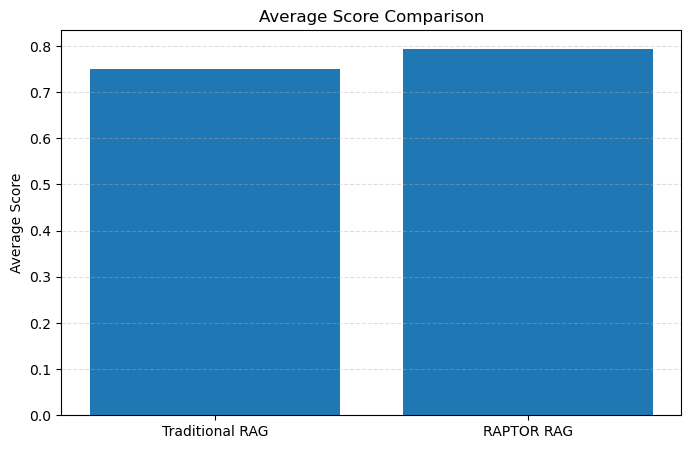

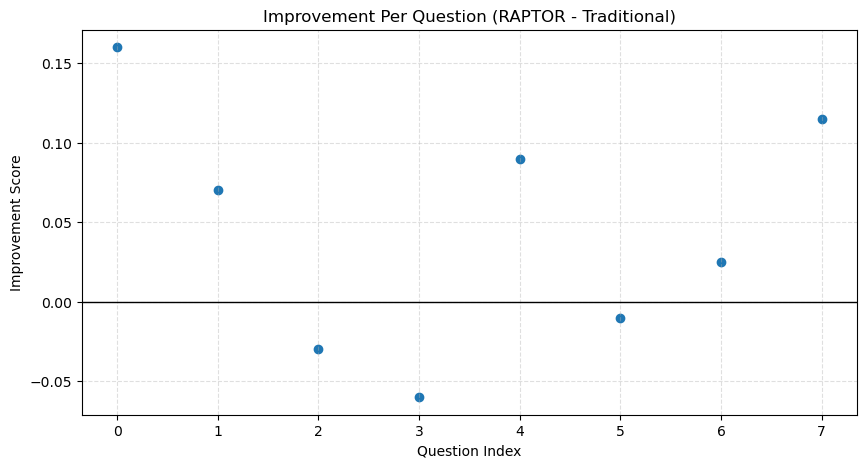

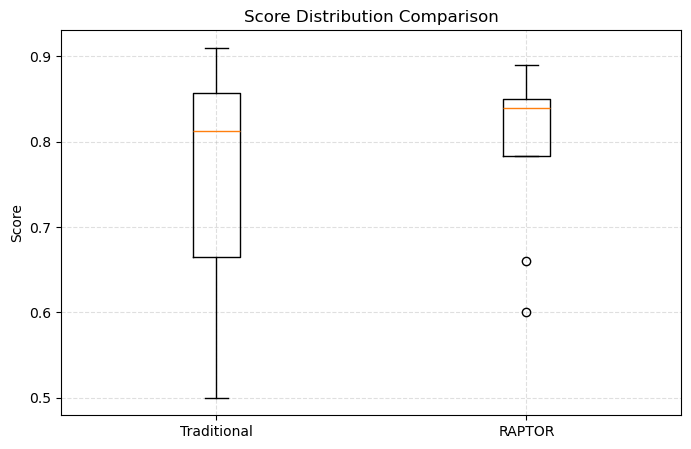

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def analyze_ollama_results(unbiased_results):
    """
    Works with YOUR result format:
    {
        "question": str,
        "traditional_score": float,
        "raptor_score": float,
        "improvement": float,
        "favors": "traditional" | "raptor" | "neither",
        "evaluation": {...} or None
    }
    """

    # Filter valid results
    results = [r for r in unbiased_results if r.get("evaluation") is not None]

    if not results:
        print("❌ No valid results to analyze.")
        return None

    # Convert to DataFrame
    df = pd.DataFrame(results)
    display(df)

    # Compute averages
    avg_trad = df["traditional_score"].mean()
    avg_raptor = df["raptor_score"].mean()
    avg_improvement = df["improvement"].mean()

    print("📊 AVERAGE PERFORMANCE")
    print(f"Traditional RAG: {avg_trad:.3f}")
    print(f"RAPTOR RAG:      {avg_raptor:.3f}")
    print(f"Improvement:     {avg_improvement:+.3f}")

    # -------------------------------
    # BAR CHART: AVERAGE COMPARISON
    # -------------------------------
    plt.figure(figsize=(8,5))
    plt.bar(["Traditional RAG", "RAPTOR RAG"], [avg_trad, avg_raptor])
    plt.title("Average Score Comparison")
    plt.ylabel("Average Score")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

    # -------------------------------
    # SCATTER PLOT: IMPROVEMENT PER QUESTION
    # -------------------------------
    plt.figure(figsize=(10,5))
    plt.scatter(range(len(df)), df["improvement"])
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Improvement Per Question (RAPTOR - Traditional)")
    plt.xlabel("Question Index")
    plt.ylabel("Improvement Score")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

    # -------------------------------
    # BOX PLOT: SCORE DISTRIBUTIONS
    # -------------------------------
    plt.figure(figsize=(8,5))
    plt.boxplot([df["traditional_score"], df["raptor_score"]],
                 labels=["Traditional", "RAPTOR"])
    plt.title("Score Distribution Comparison")
    plt.ylabel("Score")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

    return df


    return df
if unbiased_results:
    ollama_analysis_results = analyze_ollama_results(unbiased_results)


## Summary

This notebook successfully demonstrates a **complete local RAG comparison** using:

### 🏗️ **Architecture**
- **Traditional RAG**: Existing Weaviate collection + Ollama
- **RAPTOR RAG**: Hierarchical summaries + New Weaviate collection + Ollama
- **Embeddings**: Consistent all-MiniLM-L6-v2 across both systems

### 💰 **Cost & Privacy**
- **100% FREE**: No API costs for unlimited testing
- **Complete Privacy**: All processing stays local
- **No Rate Limits**: Test as much as you want

### 📊 **Real Comparison**
- No mocked data - everything uses real implementations
- Comprehensive quality metrics
- Performance analysis with actual response times
- RAPTOR abstraction level insights

### 🎯 **Perfect for Research**
- Educational: Learn how both systems work
- Experimental: Try different Ollama models
- Scalable: Add more documents and test cases
- Reproducible: All results are exportable and shareable

This provides the ideal foundation for RAG research and development!